<a href="https://colab.research.google.com/github/harini-3005/Oasis-Infobyte-task-1/blob/main/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Warehouse_and_Retail_Sales.csv to Warehouse_and_Retail_Sales (1).csv
First 5 rows:
   YEAR  MONTH                           SUPPLIER ITEM CODE  \
0  2020      1  REPUBLIC NATIONAL DISTRIBUTING CO    100009   
1  2020      1                          PWSWN INC    100024   
2  2020      1            RELIABLE CHURCHILL LLLP      1001   
3  2020      1          LANTERNA DISTRIBUTORS INC    100145   
4  2020      1               DIONYSOS IMPORTS INC    100293   

                      ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                  BOOTLEG RED - 750ML      WINE          0.00   
1            MOMENT DE PLAISIR - 750ML      WINE          0.00   
2  S SMITH ORGANIC PEAR CIDER - 18.7OZ      BEER          0.00   
3        SCHLINK HAUS KABINETT - 750ML      WINE          0.00   
4       SANTORINI GAVALA WHITE - 750ML      WINE          0.82   

   RETAIL TRANSFERS  WAREHOUSE SALES  
0               0.0              2.0  
1               1.0              4.0  
2               0

/tmp/ipython-input-1390630175.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



Descriptive Statistics:
                YEAR          MONTH   RETAIL SALES  RETAIL TRANSFERS  \
count  307645.000000  307645.000000  307645.000000     307645.000000   
mean     2018.438525       6.423862       7.024006          6.936465   
min      2017.000000       1.000000      -6.490000        -38.490000   
25%      2017.000000       3.000000       0.000000          0.000000   
50%      2019.000000       7.000000       0.320000          0.000000   
75%      2019.000000       9.000000       3.260000          3.000000   
max      2020.000000      12.000000    2739.000000       1990.830000   
std         1.083061       3.461812      30.986094         30.237195   

       WAREHOUSE SALES                           DATE  
count    307645.000000                         307645  
mean         25.294597  2018-11-21 10:26:27.489477120  
min       -7800.000000            2017-06-01 00:00:00  
25%           0.000000            2017-11-01 00:00:00  
50%           1.000000            2019-03-01 0

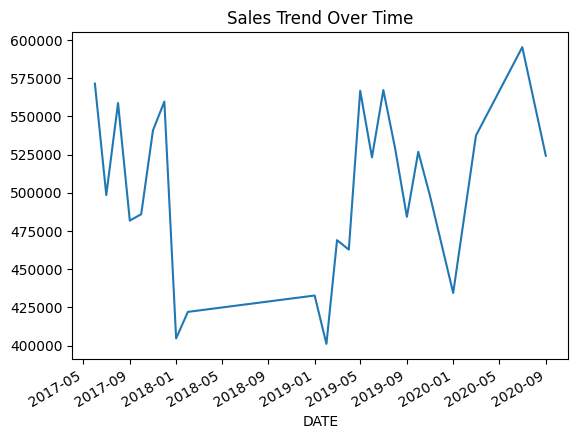

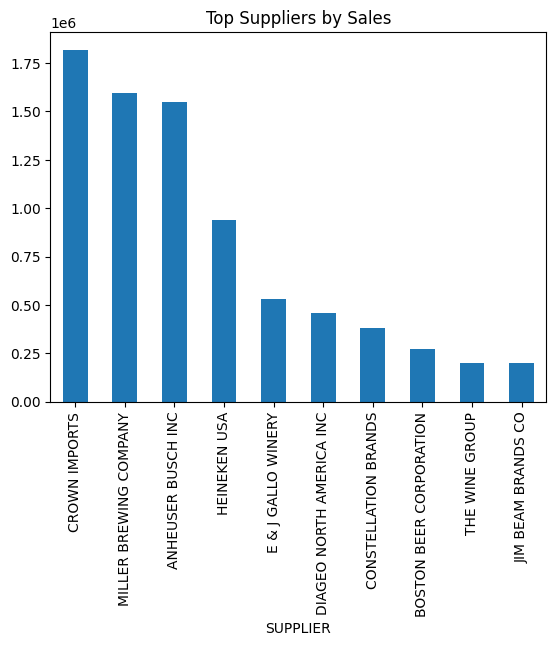

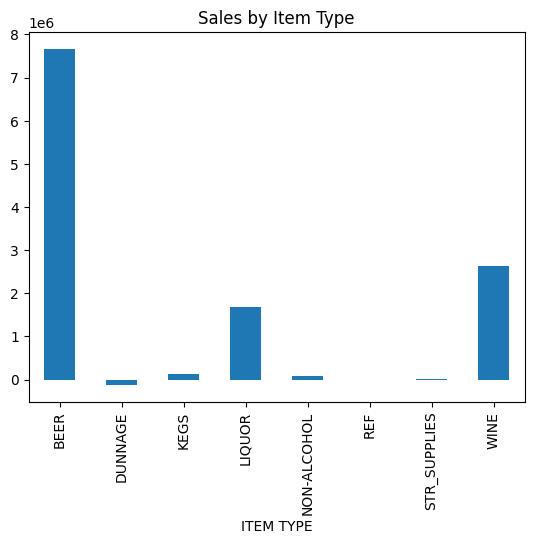

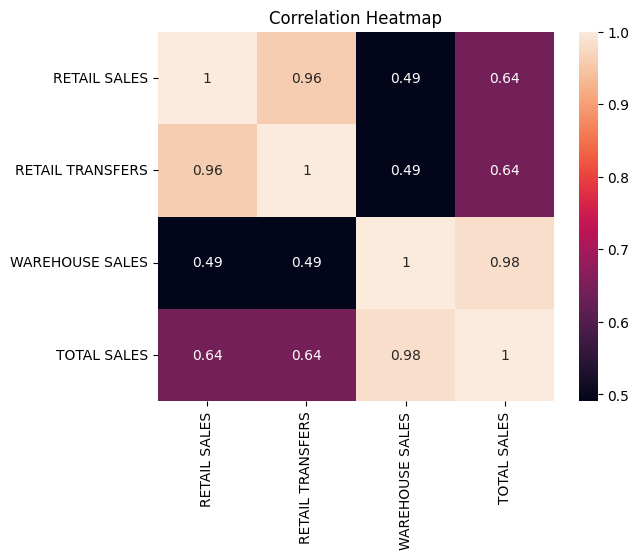

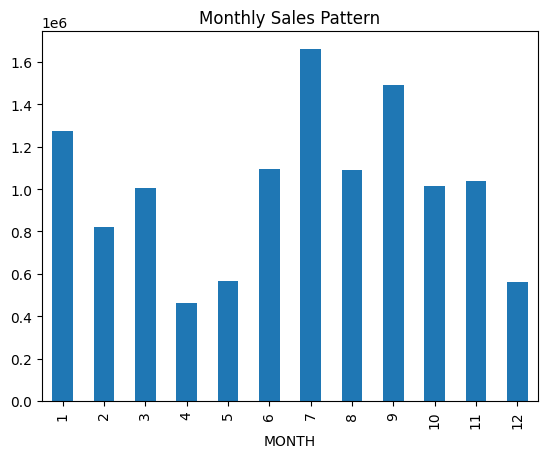


EDA Completed Successfully!


In [ ]:
# =========================================
# EDA ON RETAIL SALES DATA
# =========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset
# Upload your dataset manually in Colab
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

# 3. Display Data
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 4. Data Cleaning
# Fill missing numeric values with median
numeric_cols = ['RETAIL SALES','RETAIL TRANSFERS','WAREHOUSE SALES']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Create Date Column for Time Series
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str) + '-01')

# 5. Descriptive Statistics
print("\nDescriptive Statistics:")
print(df.describe())

# 6. Total Sales Column
df['TOTAL SALES'] = df['RETAIL SALES'] + df['RETAIL TRANSFERS'] + df['WAREHOUSE SALES']

# =========================================
# 📈 VISUALIZATION
# =========================================

# 7. Time Series Analysis
sales_trend = df.groupby('DATE')['TOTAL SALES'].sum()

plt.figure()
sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.show()

# 8. Top Suppliers
top_suppliers = df.groupby('SUPPLIER')['TOTAL SALES'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_suppliers.plot(kind='bar')
plt.title("Top Suppliers by Sales")
plt.show()

# 9. Item Type Analysis
item_type_sales = df.groupby('ITEM TYPE')['TOTAL SALES'].sum()

plt.figure()
item_type_sales.plot(kind='bar')
plt.title("Sales by Item Type")
plt.show()

# 10. Heatmap Correlation
plt.figure()
sns.heatmap(df[['RETAIL SALES','RETAIL TRANSFERS','WAREHOUSE SALES','TOTAL SALES']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 11. Monthly Sales Pattern
monthly_sales = df.groupby('MONTH')['TOTAL SALES'].sum()

plt.figure()
monthly_sales.plot(kind='bar')
plt.title("Monthly Sales Pattern")
plt.show()

print("\nEDA Completed Successfully!")
